<a href="https://colab.research.google.com/github/brunoblc/CardapioDigital/blob/master/Looqbox_teste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [180]:
!pip install mysql-connector-python


import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="35.199.115.174",
    user="looqbox-challenge",
    password="looq-challenge",
    database="looqbox-challenge"
)

**Resposta 1: 10 produtos mais caros**


**What are the 10 most expensive products in the company?**


*   *primeiro fiz no dbeaver, ai trouxe pra cá.*
select
	product_cod,
	product_name,
	product_val

from `looqbox-challenge`.data_product

order by product_val desc

limit 10;

*usei as `` pq quando o nome da tabela ou schema tem caracteres especiais, exemplo o hífen, preciso envolver com essa crase.*

In [181]:

q1 = """
SELECT product_cod, product_name, product_val
FROM `looqbox-challenge`.data_product
ORDER BY product_val DESC
LIMIT 10
"""
df_pergunta1 = pd.read_sql(q1, conn)
df_pergunta1

/tmp/ipykernel_38392/1014617084.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pergunta1 = pd.read_sql(q1, conn)


,product_cod,product_name,product_val
0,301409,Whisky Escoces THE MACALLAN Ruby Garrafa 700ml com Caixa,741.99
1,176185,Whisky Escoces JOHNNIE WALKER Blue Label Garrafa 750ml,735.90
2,315481,Cafeteira Expresso 3 CORACOES Tres Modo Vermelho,499.00
3,100280,Vinho Portugues Tinto Vintage QUINTA DO CRASTO Garrafa 750ml,445.90
4,320046,Escova Dental Eletrica ORAL B D34 Professional Care 5000 110v,399.90
5,190817,Champagne Rose VEUVE CLICQUOT PONSARDIM Garrafa 750ml,366.90
6,153795,Champagne Frances Brut Imperial MOET Rose Garrafa 750ml,359.90
7,311397,Conjunto de Panelas Allegra em Inox TRAMONTINA 5 Pecas Gratis Utensilios 5 Pecas,359.00
8,147706,Whisky Escoces CHIVAS REGAL 18 Anos Garrafa 750ml,329.90
9,154431,Champagne Frances Brut Imperial MOET & CHANDON Garrafa 750ml,315.90


ou, para começar no 1 e terminar no 10

In [182]:
df_pergunta1.index = range(1, len(df_pergunta1) + 1)
df_pergunta1

,product_cod,product_name,product_val
1,301409,Whisky Escoces THE MACALLAN Ruby Garrafa 700ml com Caixa,741.99
2,176185,Whisky Escoces JOHNNIE WALKER Blue Label Garrafa 750ml,735.90
3,315481,Cafeteira Expresso 3 CORACOES Tres Modo Vermelho,499.00
4,100280,Vinho Portugues Tinto Vintage QUINTA DO CRASTO Garrafa 750ml,445.90
5,320046,Escova Dental Eletrica ORAL B D34 Professional Care 5000 110v,399.90
6,190817,Champagne Rose VEUVE CLICQUOT PONSARDIM Garrafa 750ml,366.90
7,153795,Champagne Frances Brut Imperial MOET Rose Garrafa 750ml,359.90
8,311397,Conjunto de Panelas Allegra em Inox TRAMONTINA 5 Pecas Gratis Utensilios 5 Pecas,359.00
9,147706,Whisky Escoces CHIVAS REGAL 18 Anos Garrafa 750ml,329.90
10,154431,Champagne Frances Brut Imperial MOET & CHANDON Garrafa 750ml,315.90


**Resposta 2 - departamentos BEBIDAS e PADARIA**

**What sections do the 'BEBIDAS' and 'PADARIA' departments have?**\

Via Dbeaver

SELECT DISTINCT
    dep_name,
    section_cod,
    section_name
FROM
`looqbox-challenge`.data_product
WHERE
dep_name IN ('BEBIDAS', 'PADARIA')
ORDER
BY dep_name ASC, section_cod DESC

o order by assim, é pelo fato que se eu classifico: order by dep_name, section_name, a visualização dos section_cod não fica ordenado.

In [183]:
q2 = """
SELECT DISTINCT
    dep_name,
    section_cod,
    section_name
FROM `looqbox-challenge`.data_product
WHERE dep_name IN ('BEBIDAS', 'PADARIA')
ORDER BY dep_name ASC, section_cod DESC
"""

df_pergunta2 = pd.read_sql(q2, conn)
df_pergunta2

/tmp/ipykernel_38392/1314583610.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pergunta2 = pd.read_sql(q2, conn)


,dep_name,section_cod,section_name
0,BEBIDAS,31,REFRESCOS
1,BEBIDAS,30,VINHOS
2,BEBIDAS,29,CERVEJAS
3,BEBIDAS,4,BEBIDAS
4,PADARIA,27,GESTANTE
5,PADARIA,22,QUEIJOS-E-FRIOS
6,PADARIA,19,PADARIA
7,PADARIA,8,DOCES-E-SOBREMESAS


Eliminando o zero

In [184]:
df_pergunta2.index = range(1, len(df_pergunta2) + 1)
df_pergunta2

,dep_name,section_cod,section_name
1,BEBIDAS,31,REFRESCOS
2,BEBIDAS,30,VINHOS
3,BEBIDAS,29,CERVEJAS
4,BEBIDAS,4,BEBIDAS
5,PADARIA,27,GESTANTE
6,PADARIA,22,QUEIJOS-E-FRIOS
7,PADARIA,19,PADARIA
8,PADARIA,8,DOCES-E-SOBREMESAS


Respondendo a questão da pergunta, eu agrupo as seções para facilitar a visualização

In [185]:
pd.set_option('display.max_colwidth', None)
query2 = """
SELECT
    dep_name as Departamento,
    COUNT(DISTINCT section_name) AS Secoes_Totais,
    GROUP_CONCAT(DISTINCT section_name ORDER BY section_name) AS Secoes
FROM `looqbox-challenge`.data_product
WHERE dep_name IN ('BEBIDAS', 'PADARIA')
GROUP BY dep_name
"""

df_pergunta2 = pd.read_sql(query2, conn)
df_pergunta2.index = range(1, len(df_pergunta2) + 1)
df_pergunta2

/tmp/ipykernel_38392/3292867918.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pergunta2 = pd.read_sql(query2, conn)


,Departamento,Secoes_Totais,Secoes
1,BEBIDAS,4,"BEBIDAS,CERVEJAS,REFRESCOS,VINHOS"
2,PADARIA,4,"DOCES-E-SOBREMESAS,GESTANTE,PADARIA,QUEIJOS-E-FRIOS"


**Resposta 3 - Total de vendas por B.A no primeiro tri 2019**

**What was the total sale of products (in $) of each Business Area in the first quarter of 2019?**

Dbeaver

SELECT
    S_Cad.BUSINESS_NAME,
    ROUND(SUM(S_Sales.SALES_VALUE), 2) AS Total_Sales
FROM `looqbox-challenge`.data_store_sales S_Sales
JOIN `looqbox-challenge`.data_store_cad S_Cad
    ON S_Sales.STORE_CODE = S_Cad.STORE_CODE
WHERE S_Sales.DATE BETWEEN '2019-01-01' AND '2019-03-31'
GROUP BY S_Cad.BUSINESS_CODE, S_Cad.BUSINESS_NAME
ORDER BY Total_Sales DESC;

In [186]:
query3 = """
SELECT
    S_Cad.BUSINESS_NAME,
    ROUND(SUM(S_Sales.SALES_VALUE), 2) AS Total_Sales
FROM `looqbox-challenge`.data_store_sales S_Sales
JOIN `looqbox-challenge`.data_store_cad S_Cad
    ON S_Sales.STORE_CODE = S_Cad.STORE_CODE
WHERE S_Sales.DATE BETWEEN '2019-01-01' AND '2019-03-31'
GROUP BY S_Cad.BUSINESS_CODE, S_Cad.BUSINESS_NAME
ORDER BY Total_Sales DESC
"""

df_pergunta3 = pd.read_sql(query3, conn)
df_pergunta3

/tmp/ipykernel_38392/4186293751.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_pergunta3 = pd.read_sql(query3, conn)


,BUSINESS_NAME,Total_Sales
0,Farma,81776691.73
1,Varejo,81032347.65
2,Atacado,80384884.60
3,Proximidade,80171122.80
4,Posto,32072326.40


Ajustando pra começar em 1

In [187]:
df_pergunta3.index = range(1, len(df_pergunta3) + 1)
df_pergunta3

,BUSINESS_NAME,Total_Sales
1,Farma,81776691.73
2,Varejo,81032347.65
3,Atacado,80384884.60
4,Proximidade,80171122.80
5,Posto,32072326.40


Para formatar em moeda ($)

In [188]:
df_pergunta3['Total_Sales'] = df_pergunta3['Total_Sales'].apply(lambda x: f"$ {x:,.2f}")
df_pergunta3

,BUSINESS_NAME,Total_Sales
1,Farma,"$ 81,776,691.73"
2,Varejo,"$ 81,032,347.65"
3,Atacado,"$ 80,384,884.60"
4,Proximidade,"$ 80,171,122.80"
5,Posto,"$ 32,072,326.40"


Case 1

Função retrieve_data

usei where 1 = 1 para que sempre traga o verdadeiro, assim o código funciona independente do filtro

o select * resolve o problema de recupar tudo da tabela data_product_sales
e sobre flexibilidade, como tds os parametros tem none como padrão, qualquer um pode chamar a função de várias formas. Assim tudo se adapta a qualquer combinação de filtro.

In [189]:
def retrieve_data(product_code=None, store_code=None, date=None):

    query = """
    SELECT *
    FROM `looqbox-challenge`.data_product_sales
    WHERE 1=1
    """

    if product_code:
        query += f" AND PRODUCT_CODE = {product_code}"

    if store_code:
        query += f" AND STORE_CODE = {store_code}"

    if date:
        query += f" AND DATE BETWEEN '{date[0]}' AND '{date[1]}'"

    return pd.read_sql(query, conn)


In [190]:
my_data = retrieve_data(product_code=None, store_code=None, date=['2019-01-01', '2019-01-31'])
my_data

/tmp/ipykernel_38392/1519415433.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,STORE_CODE,PRODUCT_CODE,DATE,SALES_VALUE,SALES_QTY
0,1,18,2019-01-01,708.50,65.0
1,1,18,2019-01-02,1297.10,119.0
2,1,18,2019-01-03,1144.50,105.0
3,1,18,2019-01-04,1090.00,100.0
4,1,18,2019-01-05,893.80,82.0
...,...,...,...,...,...
39396,9,241404,2019-01-27,5127.75,129.0
39397,9,241404,2019-01-28,4730.25,119.0
39398,9,241404,2019-01-29,4929.00,124.0
39399,9,241404,2019-01-30,9301.50,234.0


Case 2 - Ticket Médio por Loja

vou separar por partes


In [191]:
query_store_cad = """
SELECT
    STORE_CODE,
    STORE_NAME,
    START_DATE,
    END_DATE,
    BUSINESS_NAME,
    BUSINESS_CODE
FROM `looqbox-challenge`.data_store_cad
"""

query_store_sales = """
SELECT
    STORE_CODE,
    DATE,
    SALES_VALUE,
    SALES_QTY
FROM `looqbox-challenge`.data_store_sales
WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'
"""

In [192]:
df_store_cad = pd.read_sql(query_store_cad, conn)
df_store_sales = pd.read_sql(query_store_sales, conn)

/tmp/ipykernel_38392/77953797.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_store_cad = pd.read_sql(query_store_cad, conn)
/tmp/ipykernel_38392/77953797.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_store_sales = pd.read_sql(query_store_sales, conn)


Filtro de período

In [193]:
df_store_sales['DATE'] = pd.to_datetime(df_store_sales['DATE'])
df_store_sales = df_store_sales[(df_store_sales['DATE'] >= '2019-10-01') & (df_store_sales['DATE'] <= '2019-12-31')]

Juntar as duas tabelas

In [194]:
df_joined = df_store_sales.merge(df_store_cad, on='STORE_CODE')

Calcular o TM por store

In [195]:
df_tm = df_joined.groupby(['STORE_NAME', 'BUSINESS_NAME']).agg(
    SALES_VALUE=('SALES_VALUE', 'sum'),
    SALES_QTY=('SALES_QTY', 'sum')
).reset_index()

df_tm['TM'] = (df_tm['SALES_VALUE'] / df_tm['SALES_QTY']).round(2)

df_resultado = df_tm[['STORE_NAME', 'BUSINESS_NAME', 'TM']].rename(columns={'STORE_NAME': 'Loja','BUSINESS_NAME': 'Categoria',})


In [196]:
df_resultado.index = range(1, len(df_resultado) + 1)
df_resultado

,Loja,Categoria,TM
1,Bahia,Atacado,15.39
2,Bangkok,Posto,13.67
3,Belem,Proximidade,15.37
4,Berlin,Proximidade,15.39
5,Buenos Aires,Atacado,15.39
6,Chicago,Varejo,15.53
7,Dubai,Atacado,15.39
8,Hong Kong,Farma,26.35
9,London,Farma,28.99
10,Madri,Farma,29.03


Case 3

Visualizações IMDB

In [197]:
df_imdb = pd.read_sql("SELECT * FROM `looqbox-challenge`.IMDB_movies LIMIT 5", conn)
df_imdb

/tmp/ipykernel_38392/682887572.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_imdb = pd.read_sql("SELECT * FROM `looqbox-challenge`.IMDB_movies LIMIT 5", conn)


,Id,Title,Genre,Director,Actors,Year,Runtime,Rating,Votes,RevenueMillions,Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe Saldana",2014,121,8.0,757074,333.0,76
1,2,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fassbender, Charlize Theron",2012,124,7.0,485820,126.0,65
2,3,Split,"Horror,Thriller",M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richardson, Jessica Sula",2016,117,7.0,157606,138.0,62
3,4,Sing,"Animation,Comedy,Family",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth MacFarlane, Scarlett Johansson",2016,108,7.0,60545,270.0,59
4,5,Suicide Squad,"Action,Adventure,Fantasy",David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola Davis",2016,123,6.0,393727,325.0,40


Top 10 filmes por receita

/tmp/ipykernel_38392/741929931.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_imdb = pd.read_sql("SELECT * FROM `looqbox-challenge`.IMDB_movies", conn)


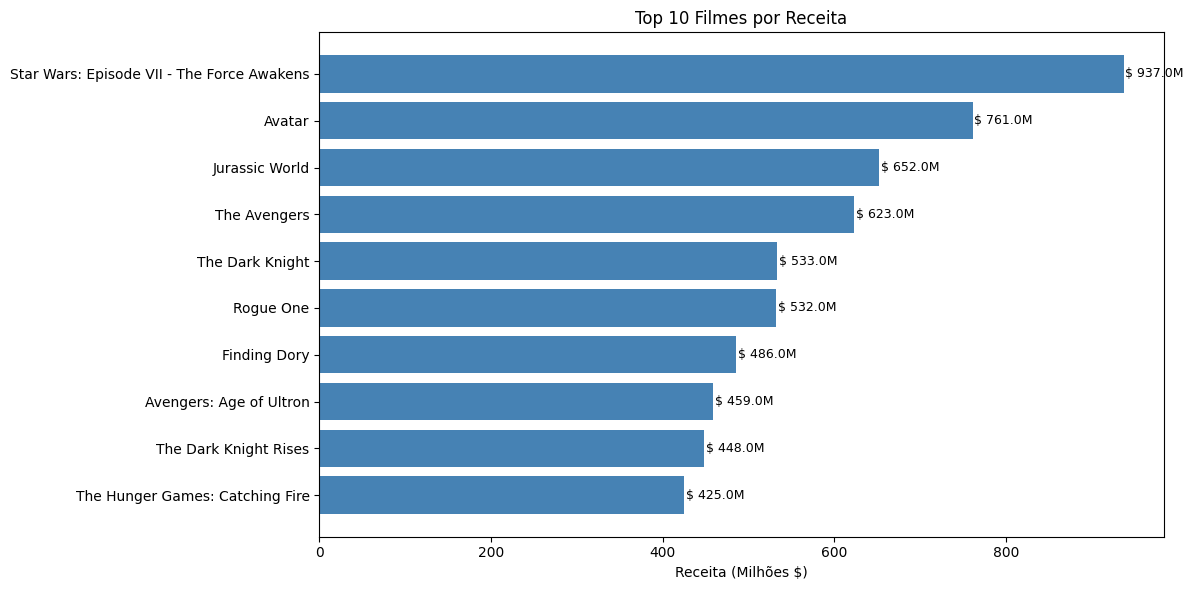

In [198]:
import matplotlib.pyplot as plt

df_imdb = pd.read_sql("SELECT * FROM `looqbox-challenge`.IMDB_movies", conn)

df_revenue = df_imdb.dropna(subset=['RevenueMillions'])
df_top10 = df_revenue.nlargest(10, 'RevenueMillions')

plt.figure(figsize=(12, 6))
bars = plt.barh(df_top10['Title'], df_top10['RevenueMillions'], color='steelblue')
plt.xlabel('Receita (Milhões $)')
plt.title('Top 10 Filmes por Receita')
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2,
             f'$ {width:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Atores que mais foram contratados

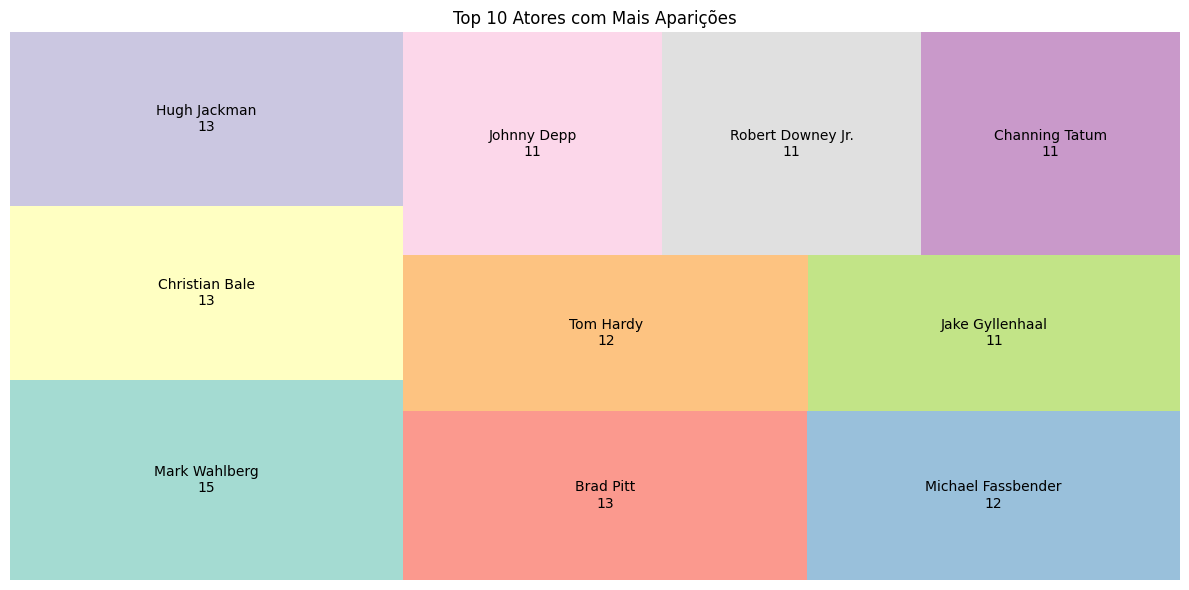

In [199]:
!pip install squarify

import squarify
import numpy as np

from collections import Counter

atores = df_imdb['Actors'].dropna().str.split(', ')
todos_atores = [ator for lista in atores for ator in lista]
top_atores = Counter(todos_atores).most_common(10)
df_atores = pd.DataFrame(top_atores, columns=['Ator', 'Aparições'])

plt.figure(figsize=(12, 6))
squarify.plot(sizes=df_atores['Aparições'],
              label=[f"{a}\n{v}" for a, v in zip(df_atores['Ator'], df_atores['Aparições'])],
              color=plt.cm.Set3.colors, alpha=0.8)
plt.title('Top 10 Atores com Mais Aparições')
plt.axis('off')
plt.tight_layout()
plt.show()

Avaliação por Gênero

<Figure size 1200x600 with 0 Axes>

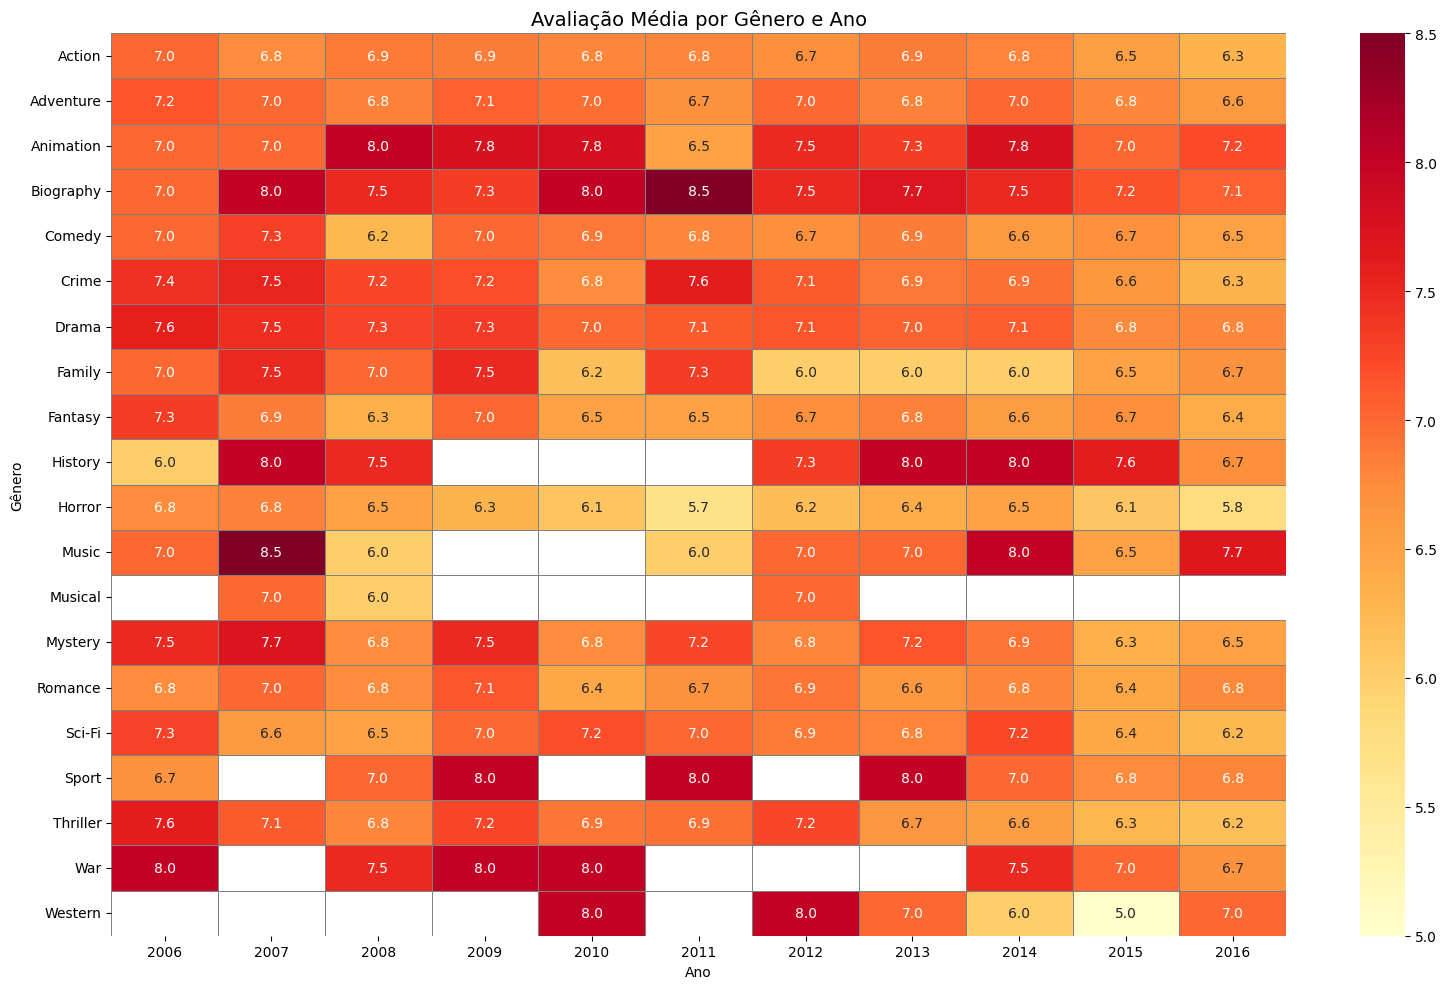

In [200]:
import seaborn as sns
df_heat = df_imdb.copy()
df_heat['Genre'] = df_heat['Genre'].str.split(',')
df_heat = df_heat.explode('Genre')
df_heat['Genre'] = df_heat['Genre'].str.strip()

df_pivot = df_heat.groupby(['Genre', 'Year'])['Rating'].mean().round(2).unstack()
plt.figure(figsize=(12, 6))
plt.figure(figsize=(16, 10))
sns.heatmap(df_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='gray')
plt.title('Avaliação Média por Gênero e Ano', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Gênero')
plt.tight_layout()
plt.show()

Pontuação e Votos por Gênero

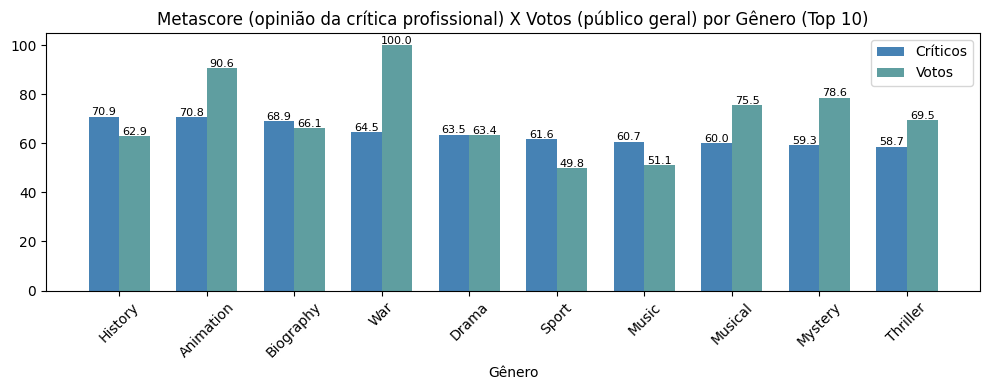

In [201]:
df_genero4 = df_imdb.copy()
df_genero4['Genre'] = df_genero4['Genre'].str.split(',')
df_genero4 = df_genero4.explode('Genre')
df_genero4['Genre'] = df_genero4['Genre'].str.strip()

df_meta_votes = df_genero4.groupby('Genre').agg(
    Metascore=('Metascore', 'mean'),
    Votes=('Votes', 'mean')
).round(2).sort_values('Metascore', ascending=False).head(10).reset_index()

df_meta_votes['Votes_norm'] = (df_meta_votes['Votes'] / df_meta_votes['Votes'].max()) * 100

x = np.arange(len(df_meta_votes['Genre']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
bars1 = ax.bar(x - width/2, df_meta_votes['Metascore'], width, label='Críticos', color='steelblue')
bars2 = ax.bar(x + width/2, df_meta_votes['Votes_norm'], width, label='Votos', color='cadetblue')

ax.set_xlabel('Gênero')
ax.set_title('Metascore (opinião da crítica profissional) X Votos (público geral) por Gênero (Top 10)')
ax.set_xticks(x)
ax.set_xticklabels(df_meta_votes['Genre'], rotation=45)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [204]:
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/Looqbox-teste.ipynb" --log-level WARN 2>/dev/null